# Setup & Imports

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from src.config import INTERIM_DATA_DIR

In [2]:
# Load datasets
internship_postings = pd.read_parquet(INTERIM_DATA_DIR / "internship_postings.parquet")
display(internship_postings.sample(10))

,job_id,published_at,job_title,job_category,company,regency_city,province,allowed_major,allows_all_majors,allows_bachelor_level,...,job_description,weekly_working_day,requested_quota_category,approved_quota_category,applicant_count_category,acceptance_percentage_category,requested_quota,approved_quota,applicant_count,acceptance_percentage
11622,a241ebe1-349f-4015-8c9f-cc745cab340f,2026-07-16T10:12:53+07:00,Manajemen Risiko,"Legal, Risk & Compliance",PT Transportasi Jakarta,Kota Adm. Jakarta Timur,DKI Jakarta,"Manajemen, Teknik Industri, Statistika",No,Yes,...,Mendukung pelaksanaan pengelolaan manajemen ri...,5,1 to 2,1 to 2,11 to 20,11 - 25%,2,2,12,15.38
15441,a240ebd7-e3cb-4056-bc19-1bac4e4bfae7,2026-07-16T12:20:40+07:00,PERAWAT,Healthcare & Medical,LEMBAGA PEMASYARAKATAN KELAS IIB SELONG,Kab. Lombok Timur,Nusa Tenggara Barat,"Keperawatan, Kesehatan Masyarakat, Ilmu Kepera...",No,Yes,...,Membantu pelayanan kesehatan dasar bagi warga ...,5,1 to 2,1 to 2,6 to 10,11 - 25%,1,1,8,11.11
21501,a241818c-9a10-405f-95bf-cd96333cfb1e,2026-07-16T12:45:52+07:00,PENGELOLA SDM,"HR, Admin & Management",LEMBAGA PEMASYARAKATAN KELAS III MAMASA,Kab. Mamasa,Sulawesi Barat,"Manajemen, Manajemen Administrasi, Manajemen A...",No,Yes,...,1. Mengumpulkan data dan informasi yang releva...,6,1 to 2,1 to 2,11 to 20,0 - 10%,1,1,12,7.69
8963,a235022b-acd6-462d-8397-55af09e2fdd0,2026-07-16T09:53:11+07:00,Finance Accounting Admin,Finance & Banking,Gobel Sigma Indonesia,Kota Adm. Jakarta Selatan,DKI Jakarta,"Akuntansi Keuangan, Akuntansi Keuangan Perusah...",No,Yes,...,1. Mengelola dan mengarsipkan dokumen keuangan...,5,1 to 2,1 to 2,11 to 20,11 - 25%,2,2,11,16.67
26290,a240e9e0-457e-4881-a4ec-3c9fdb427a49,2026-07-16T12:51:03+07:00,Duta Layanan,"Sales, Marketing & Hospitality",RUMAH TAHANAN NEGARA KELAS IIB TAPAK TUAN,Kab. Aceh Selatan,Aceh,"Manajemen, Ilmu Administrasi Publik, Ilmu Komu...",No,Yes,...,Duta Layanan Kunjungan bertugas memberikan pel...,6,1 to 2,1 to 2,11 to 20,0 - 10%,1,1,20,4.76
9639,a2410882-3053-442d-983f-3465fba21e91,2026-07-16T12:33:51+07:00,PENGELOLA BMN,"HR, Admin & Management",KANIM KELAS II TPI SAMPIT,Kab. Kotawaringin Timur,Kalimantan Tengah,Manajemen Aset Publik,No,Yes,...,1. Mengelola aset dan inventaris milik negara ...,5,1 to 2,1 to 2,6 to 10,11 - 25%,1,1,6,14.29
23058,a241844e-616b-4e7c-8873-6138112ed445,2026-07-16T10:42:57+07:00,Staf Sumber Daya Manusia RS Gatoel,"HR, Admin & Management",Nusantara Medika Utama,Kota Mojokerto,Jawa Timur,"Manajemen Sumber Daya Manusia, Manajemen, Admi...",No,Yes,...,Bertanggung jawab atas administrasi umum kepeg...,5,1 to 2,1 to 2,21 to 50,0 - 10%,2,2,26,7.41
15625,a2441bd5-45ac-4d89-833e-06fff1472a51,2026-07-16T12:02:40+07:00,Analis Kerja Sama Dalam Negeri,Other,PERWAKILAN JAWA TENGAH,Kota Adm. Jakarta Selatan,DKI Jakarta,"Ilmu Komunikasi, Hukum",No,Yes,...,• Membantu penyusunan dan penyiapan dokumen ke...,5,1 to 2,1 to 2,6 to 10,11 - 25%,1,1,8,11.11
606,a2416212-c153-4585-870d-ad3d424e8471,2026-07-16T12:56:44+07:00,PENGELOLA KEGIATAN KERJA PERKEBUNAN,Agriculture & Environment,LEMBAGA PEMASYARAKATAN NARKOTIKA KELAS IIA KAS...,Kab. Katingan,Kalimantan Tengah,Budidaya Perkebunan,No,Yes,...,1.\tMenyusun rencana dan mengelola kegiatan ke...,6,1 to 2,1 to 2,0 to 5,26 - 50%,1,1,2,33.33
3792,a23f40d7-11e7-49e3-aa3f-1673d6212fe3,2026-07-16T12:13:02+07:00,PENGELOLA KEHUMASAN,"Media, PR & Creative",KANTOR WILAYAH DIREKTORAT JENDERAL PEMASYARAKA...,Kota Denpasar,Bali,Komunikasi,No,Yes,...,1. Menyusun materi layanan informasi untuk med...,5,1 to 2,1 to 2,0 to 5,11 - 25%,1,1,4,20.00


In [ ]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Univariate Analysis
##  1.1 Numerical Features

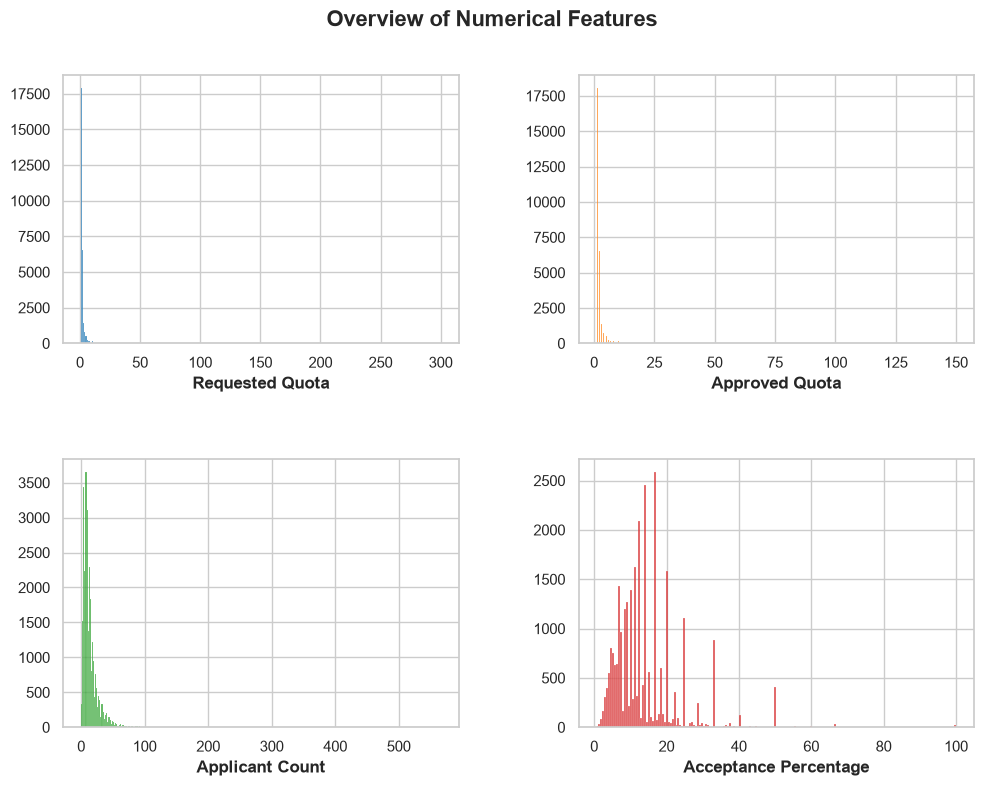

In [ ]:
# Plot the numerical features
# Manually prepare the columns to visualize
plotted_cols = ["requested_quota", "approved_quota", "applicant_count", "acceptance_percentage"]

# Generate a list of distinct colors (one for each column)
# palette: bright, Set1, tab10, Set2
colors = sns.color_palette("tab10", len(plotted_cols))

# Set the canvas
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot distributions
for ax, col, color in zip(axes.flat, plotted_cols, colors):
    sns.histplot(internship_postings, x=col, ax=ax, color=color)
    ax.set_xlabel(col.replace("_", " ").title(), fontweight="bold")
    ax.set_ylabel(None)

# Set the main title
fig.suptitle("Overview of Numerical Features", fontsize=16, fontweight="bold")

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

## 1.2 Categorical Features

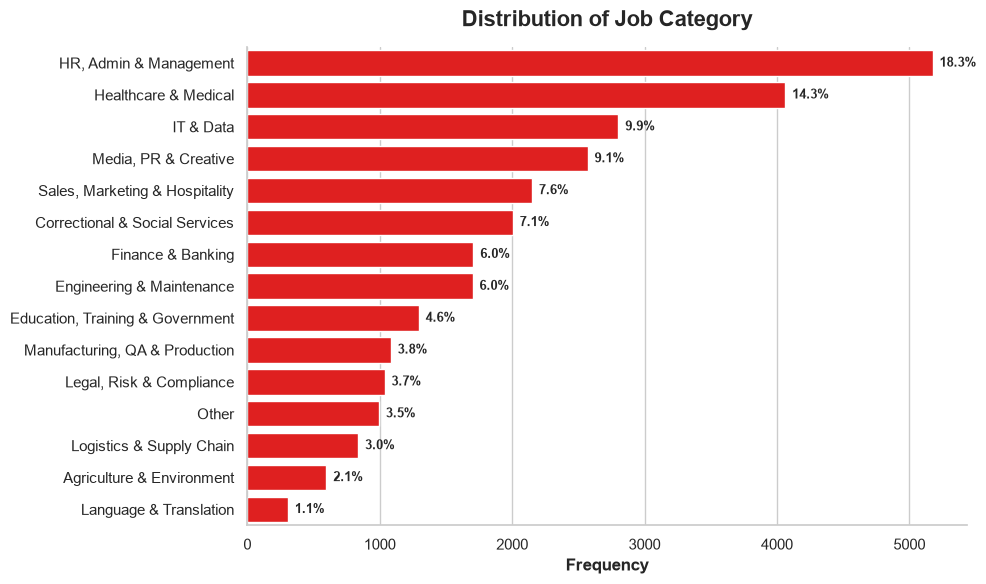

In [ ]:
# Plot the job category distribution
# Set the target column
target_col = "job_category"
total_rows = len(internship_postings)

# Pre-calculate and sort frequencies for readability
category_counts = internship_postings[target_col].value_counts().reset_index()
category_counts.columns = [target_col, "count"]

# Set the canvas
fig, ax = plt.subplots(figsize=(10, 6))

# Plot `province`
sns.barplot(
    data=category_counts, 
    y=target_col, 
    x="count", 
    color="red",
    ax=ax
)

# Add exact percentages to the end of the bars
for container in ax.containers:
    # Use bar.get_width() because the bars are now horizontal
    labels = [f"{(bar.get_width() / total_rows) * 100:.1f}%" for bar in container]
    ax.bar_label(container, labels=labels, padding=5, fontweight="bold", fontsize=9)    # type: ignore

# Formatting
ax.set_title(
    f"Distribution of {target_col.replace("_", " ").title()}",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("")
ax.set_xlabel("Frequency")

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

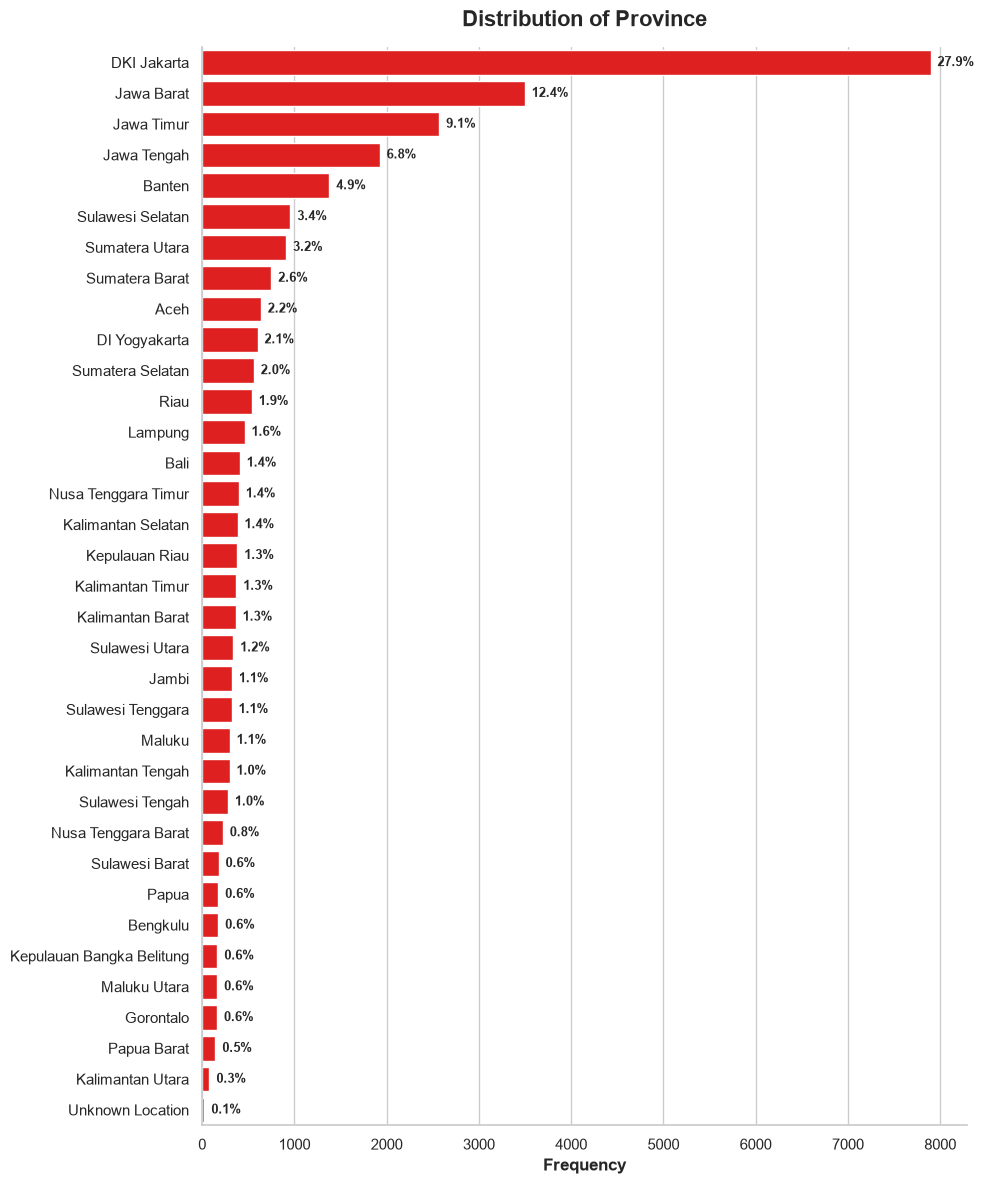

In [ ]:
# Plot the province distribution
# Set the target column
target_col = "province"
total_rows = len(internship_postings)

# Pre-calculate and sort frequencies for readability
category_counts = internship_postings[target_col].value_counts().reset_index()
category_counts.columns = [target_col, "count"]

# Set the canvas
fig, ax = plt.subplots(figsize=(10, 12))

# Plot `province`
sns.barplot(
    data=category_counts, 
    y=target_col, 
    x="count", 
    color="red",
    ax=ax
)

# Add exact percentages to the end of the bars
for container in ax.containers:
    # Use bar.get_width() because the bars are now horizontal
    labels = [f"{(bar.get_width() / total_rows) * 100:.1f}%" for bar in container]
    ax.bar_label(container, labels=labels, padding=5, fontsize=9)    # type: ignore

# Formatting
ax.set_title(
    f"Distribution of {target_col.replace("_", " ").title()}",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("")
ax.set_xlabel("Frequency")

# Remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

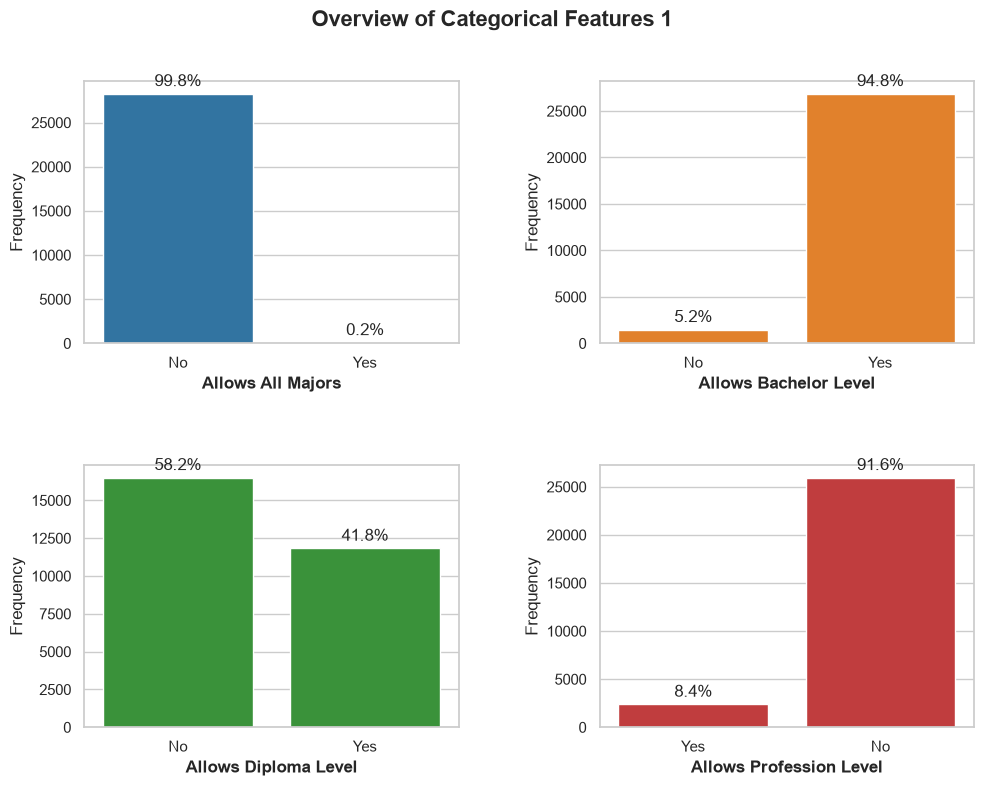

In [ ]:
# Plot the remaining categorical features
# Manually prepare the columns to visualize
plotted_cols = ["allows_all_majors", "allows_bachelor_level", "allows_diploma_level", "allows_profession_level"]

# Generate a list of distinct colors (one for each column)
# palette: bright, Set1, tab10, Set2
colors = sns.color_palette("tab10", len(plotted_cols))

# Get the total number of rows to calculate percentages
total_rows = len(internship_postings)

# Set the canvas
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot distributions
for ax, col, color in zip(axes.flat, plotted_cols, colors):
    sns.countplot(internship_postings, x=col, ax=ax, color=color)
    
    # Calculate and display exact percentages on top of bars
    for container in ax.containers:
        labels = [f"{(bar.get_height() / total_rows) * 100:.1f}%" for bar in container]
        ax.bar_label(container, labels=labels, padding=3)
        
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Frequency")

# Set the main title
fig.suptitle("Overview of Categorical Features 1", fontsize=16, fontweight="bold")

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

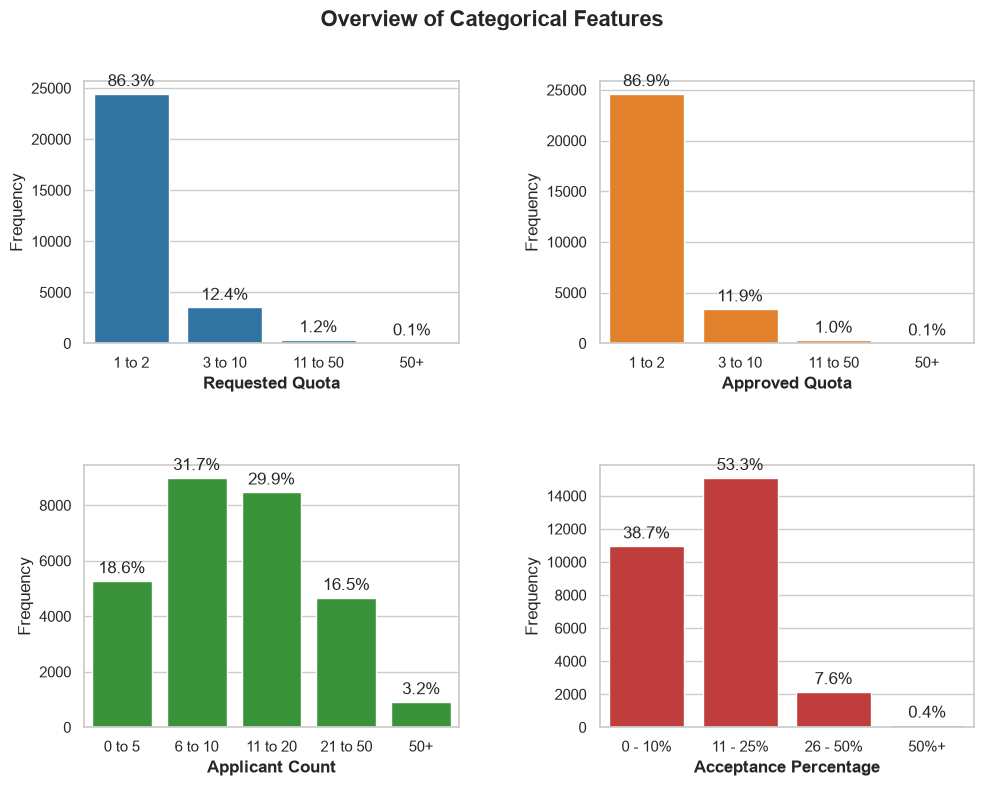

In [ ]:
# Plot the categorical features
# Manually prepare the columns to visualize
plotted_cols = ["requested_quota_category", "approved_quota_category", "applicant_count_category", "acceptance_percentage_category"]

# Generate a list of distinct colors (one for each column)
# palette: bright, Set1, tab10, Set2
colors = sns.color_palette("tab10", len(plotted_cols))

# Get the total number of rows to calculate percentages
total_rows = len(internship_postings)

# Set the canvas
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot distributions
for ax, col, color in zip(axes.flat, plotted_cols, colors):
    sns.countplot(internship_postings, x=col, ax=ax, color=color)
    
    # Calculate and display exact percentages on top of bars
    for container in ax.containers:
        labels = [f"{(bar.get_height() / total_rows) * 100:.1f}%" for bar in container]
        ax.bar_label(container, labels=labels, padding=3)
        
    ax.set_xlabel(col.removesuffix("_category").replace("_", " ").title())
    ax.set_ylabel("Frequency")

# Set the main title
fig.suptitle("Overview of Categorical Features", fontsize=16, fontweight="bold")

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

# 2. Bivariate Analysis
## 2.1 Categorical vs. Numerical (Performance)
### 2.1.1 Side-by-Side Boxplots
Mapping `applicant_count` and `acceptance_percentage` against `job_category` and `province`.

In [ ]:
# Order categories by job count for intuitive visual hierarchy
job_order = internship_postings.job_category.value_counts().sort_values(ascending=False).index
province_order = internship_postings.province.value_counts().sort_values(ascending=False).head(10).index

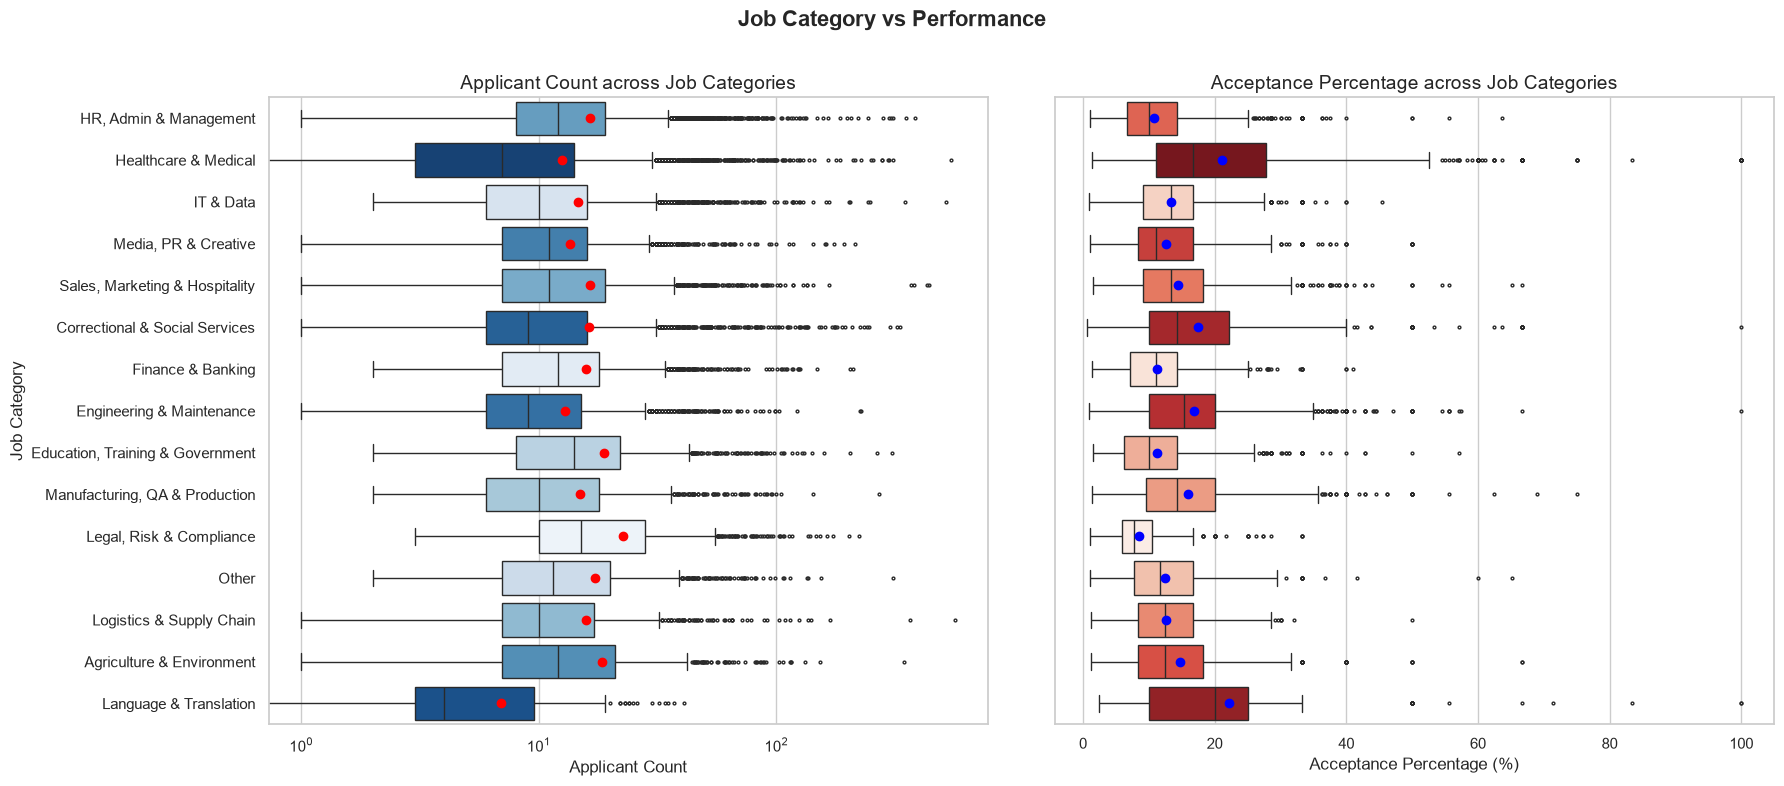

In [31]:
# Job Category vs Performance
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

# Set the main title
fig.suptitle("Job Category vs Performance", fontsize=16, fontweight="bold")

sns.boxplot(
    data=internship_postings,
    y="job_category",
    x="applicant_count",
    hue="job_category",
    legend=False,
    order=job_order,
    ax=axes[0],
    palette="Blues_r",
    fliersize=2,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
)
axes[0].set_title("Applicant Count across Job Categories", fontsize=14)
axes[0].set_xlabel("Applicant Count")
axes[0].set_ylabel("Job Category")
axes[0].set_xscale("log")  # Due to the heavily right-skewed distribution

sns.boxplot(
    data=internship_postings,
    x="acceptance_percentage",
    y="job_category",
    hue="job_category",
    legend=False,
    order=job_order,
    ax=axes[1],
    palette="Reds_r",
    fliersize=2,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "blue",
        "markeredgecolor": "blue",
    },
)
axes[1].set_title("Acceptance Percentage across Job Categories", fontsize=14)
axes[1].set_xlabel("Acceptance Percentage (%)")
axes[1].set_ylabel("")
axes[1].tick_params(left=False, labelleft=False)

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

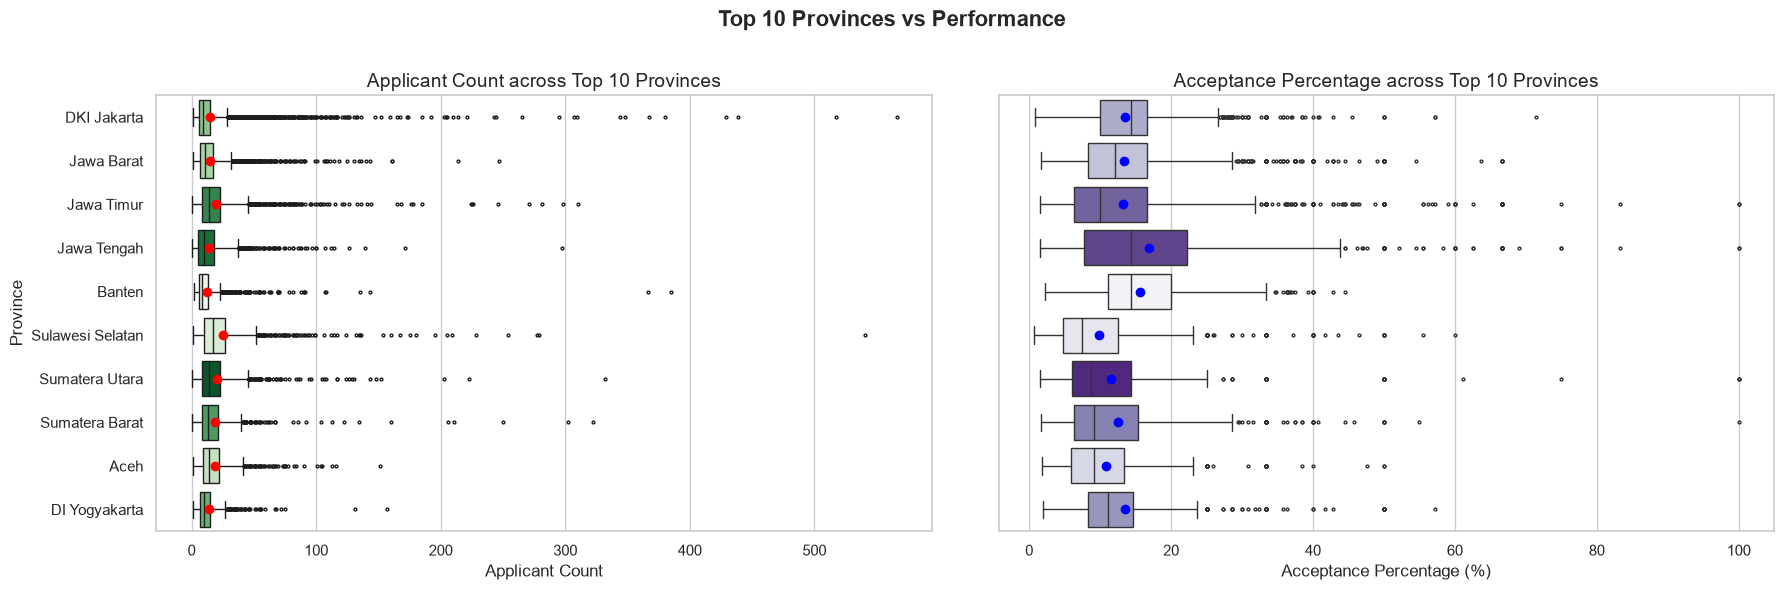

In [ ]:
# Top 10 Provinces vs Performance
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Set the main title
fig.suptitle("Top 10 Provinces vs Performance", fontsize=16, fontweight="bold")

top_prov_df = internship_postings[
    internship_postings["province"].isin(province_order.to_list())
]

sns.boxplot(
    data=top_prov_df,
    y="province",
    x="applicant_count",
    hue="province",
    legend=False,
    order=province_order,
    ax=axes[0],
    palette="Greens_r",
    fliersize=2,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
)
axes[0].set_title("Applicant Count across Top 10 Provinces", fontsize=14)
axes[0].set_xlabel("Applicant Count")
axes[0].set_ylabel("Province")

sns.boxplot(
    data=top_prov_df,
    y="province",
    x="acceptance_percentage",
    hue="province",
    legend=False,
    order=province_order,
    ax=axes[1],
    palette="Purples_r",
    fliersize=2,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "blue",
        "markeredgecolor": "blue",
    },
)
axes[1].set_title("Acceptance Percentage across Top 10 Provinces", fontsize=14)
axes[1].set_xlabel("Acceptance Percentage (%)")
axes[1].set_ylabel("")
axes[1].tick_params(left=False, labelleft=False)

# Add manual padding between subplots
plt.tight_layout(w_pad=4.0, h_pad=4.0, rect=(0, 0, 1, 0.97))
plt.show()

### 2.1.2 Global ANOVA Tests
Using ANOVA tests to see if competition significantly varies by industry or location.

This tests the null hypothesis, $H_0$, that the mean `applicant_count` and `acceptance_percentage` are equal across all categories and all provinces.

In [34]:
def run_anova(df, group_col, target_col):
    """Drops NaNs and runs one-way ANOVA across distinct groups."""
    valid_data = df[[group_col, target_col]].dropna()
    groups = [group[target_col].values for _, group in valid_data.groupby(group_col)]
    f_val, p_val = stats.f_oneway(*groups)
    print(f"ANOVA for [{target_col}] across [{group_col}]:")
    print(f"  F-Statistic : {f_val:.4f}")
    print(f"  p-value     : {p_val:.4e}")
    if p_val < 0.05:
        print("  Verdict     : Significant variation exists among group means (Reject H0).\n")
    else:
        print("  Verdict     : No statistically significant variation detected (Fail to reject H0).\n")

# Run ANOVA tests
run_anova(internship_postings, "job_category", "applicant_count")
run_anova(internship_postings, "job_category", "acceptance_percentage")
run_anova(internship_postings, "province", "applicant_count")
run_anova(internship_postings, "province", "acceptance_percentage")

ANOVA for [applicant_count] across [job_category]:
  F-Statistic : 30.8839
  p-value     : 8.8257e-83
  Verdict     : Significant variation exists among group means (Reject H0).

ANOVA for [acceptance_percentage] across [job_category]:
  F-Statistic : 370.4299
  p-value     : 0.0000e+00
  Verdict     : Significant variation exists among group means (Reject H0).

ANOVA for [applicant_count] across [province]:
  F-Statistic : 24.4219
  p-value     : 4.7875e-150
  Verdict     : Significant variation exists among group means (Reject H0).

ANOVA for [acceptance_percentage] across [province]:
  F-Statistic : 105.4940
  p-value     : 0.0000e+00
  Verdict     : Significant variation exists among group means (Reject H0).



In [17]:
cat_cols = [
    "job_category", "province", "allows_all_majors", "allows_bachelor_level", "allows_diploma_level", "allows_profession_level",
    "requested_quota_category", "approved_quota_category", "applicant_count_category", "acceptance_percentage_category"
]

for col in cat_cols:
    grouped_values = internship_postings[col].value_counts(normalize=True).mul(100).round(1).to_dict()
    print("===================================================================")
    print(f"Univariate Analysis of Column {col} - Internship Postings (%)")
    print("-------------------------------------------------------------------")
    for value, count in grouped_values.items():
        print(f"{value}: {count}%")
    print("")

Univariate Analysis of Column job_category - Internship Postings (%)
-------------------------------------------------------------------
HR, Admin & Management: 18.3%
Healthcare & Medical: 14.3%
IT & Data: 9.9%
Media, PR & Creative: 9.1%
Sales, Marketing & Hospitality: 7.6%
Correctional & Social Services: 7.1%
Finance & Banking: 6.0%
Engineering & Maintenance: 6.0%
Education, Training & Government: 4.6%
Manufacturing, QA & Production: 3.8%
Legal, Risk & Compliance: 3.7%
Other: 3.5%
Logistics & Supply Chain: 3.0%
Agriculture & Environment: 2.1%
Language & Translation: 1.1%

Univariate Analysis of Column province - Internship Postings (%)
-------------------------------------------------------------------
DKI Jakarta: 27.9%
Jawa Barat: 12.4%
Jawa Timur: 9.1%
Jawa Tengah: 6.8%
Banten: 4.9%
Sulawesi Selatan: 3.4%
Sumatera Utara: 3.2%
Sumatera Barat: 2.6%
Aceh: 2.2%
DI Yogyakarta: 2.1%
Sumatera Selatan: 2.0%
Riau: 1.9%
Lampung: 1.6%
Bali: 1.4%
Nusa Tenggara Timur: 1.4%
Kalimantan Selatan: 1

In [14]:
print(internship_postings.sample(10))

                                     job_id               published_at  \
17406  a241190f-3db3-4ac5-8652-79504cd1b8c9  2026-07-16T12:16:29+07:00   
7140   a23204ca-951a-4186-b550-2ce9a1174d0f  2026-07-16T10:24:39+07:00   
15044  a243f4b5-5ac6-431f-bdbb-616fef73d9b9  2026-07-16T22:00:20+07:00   
616    a242e327-f2ac-4054-93f4-58a2b1582951  2026-07-16T12:54:36+07:00   
2169   a240e5f8-fd9b-4866-99f3-77ff3608414a  2026-07-16T12:03:32+07:00   
18813  a240e6a5-1b51-40b1-b4ed-0642360d56dd  2026-07-16T12:59:05+07:00   
5811   a23f51ef-bc8b-4923-9e0b-103aa2e9b515  2026-07-16T13:00:19+07:00   
1448   a240ecc0-8e12-4e30-93f6-88db63cb5068  2026-07-16T12:35:18+07:00   
18949  a2430f29-93e6-446c-8560-ab9210770878  2026-07-16T12:33:35+07:00   
2564   a24386cc-6740-44e7-9f1b-1be23e270859  2026-07-16T12:42:58+07:00   

                           job_title                      job_category  \
17406  Pengelola Barang Milik Negara            HR, Admin & Management   
7140          E-Commerce OTA Listing 

In [ ]:
print(internship_postings.job_category.value_counts(normalize=True))

Notes:
* All numerical data is highly right-skewed, so assumptions for normality are unmet. Thus, proceed with non-parametric tests (which rely on medians and ranks).
* Based on the visualization of the province distribution, it is evident that most internships are concentrated in a few provinces where 27.9% in DKI Jakarta, 12.4% in West Java, 9.1% in East Java, and 6.5% in Central Java. The remaining provinces have a significantly lower representation, with less than 5% each. This indicates a strong regional preference for internships in these areas, which could be due to the presence of major cities, economic hubs, or educational institutions that attract more internship opportunities.

<!-- Findings:
* All the numerical features, `weekly_working_day`, `requested_quota`, `approved_quota`, `applicant_count`, and `acceptance_percentage`, are highly right skewed.
* Consider transforming Column `weekly_working_day` to a categorical feature, as it has only 2 unique values.
* Bin the rest of the numerical features to make logical sense to stakeholders, manually define the edges. Since the tail is long, increase the bin sizes exponentially to catch the massive outliers in a single "Extreme" bucket. -->